In [9]:
from dotenv import load_dotenv
import os
load_dotenv()  # Load environment variables from .env file

True

In [10]:
import os
import requests

class NvidiaChat:
    def __init__(self, model="moonshotai/kimi-k2.5", temperature=0.9):
        self.model = model
        self.temperature = temperature
        self.api_key = os.getenv("NVIDIA_API_KEY")
        self.url = "https://integrate.api.nvidia.com/v1/chat/completions"

        if not self.api_key:
            raise ValueError("Set NVIDIA_API_KEY environment variable")

    def __call__(self, prompt: str) -> str:
        response = requests.post(
            self.url,
            headers={
                "Authorization": f"Bearer {self.api_key}",
                "Content-Type": "application/json",
            },
            json={
                "model": self.model,
                "messages": [{"role": "user", "content": prompt}],
                "temperature": self.temperature,
            },
        )
        return response.json()["choices"][0]["message"]["content"]

In [11]:
chat_llm = NvidiaChat(model="moonshotai/kimi-k2.5", temperature=0.9)

response = chat_llm("What is the capital of France?")
print(response)

 The capital of France is **Paris**.


In [12]:
from typing_extensions import TypedDict,Annotated
import operator

In [13]:
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage, AnyMessage

In [14]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]

In [15]:
def llm_call(state:GraphState)-> dict:
    """Call the LLM using conversation messages and append AI response"""
    prompt = state["messages"][-1].content
    response = chat_llm(prompt)
    return {"messages": [AIMessage(content=response)]}

In [16]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message"""
    last_mag = state["messages"][-1]
    text = last_mag.content
    token_count = len(text.split())
    summary  = f"total token number in the generated response is {token_count}"
    return {"message": [AIMessage(content=summary)]}

In [17]:
from langgraph.graph import StateGraph
builder = StateGraph(GraphState)

In [18]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [19]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [20]:
app = builder.compile()

In [21]:
app.get_graph() 

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [22]:
from IPython.display import Image, display

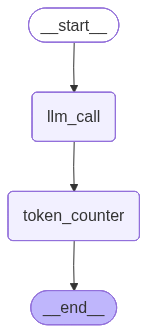

In [23]:
display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
result = app.invoke({"messages": [HumanMessage(content="What is the capital of France?")]})
print(result)


{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}), AIMessage(content=' The capital of France is **Paris**.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}


In [25]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [26]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max=500)

In [27]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [28]:
wiki_tool.run({"query":"what is  genai"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

In [29]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults()
result = tavily_tool.invoke("currect date and time")
print(result)

C:\Users\vighnesh\AppData\Local\Temp\ipykernel_6660\1200486068.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults()


[{'title': 'Time.now: Current Time Now', 'url': 'https://time.now/', 'content': 'Tue 07:17\n ### AEST\n\n   Tue 09:17\n ### IST\n\n   Tue 03:47\n ### CST\n\n   Mon 16:17\n ### UTC\n\n   Mon 22:17\n ### MST\n\n   Mon 15:17\n ### EET\n\n   Tue 00:17\n ### WET\n\n   Mon 22:17\n\n## Tools & Converters\n\nExplore our suite of free online tools.\n\nTime Calculator \n\n90 days ago 7 hours ago 30 days from now 8 hours from now 1 hour from now\n\nCities \n\nSunrise Times Sunset Times Air Quality Index")\n\nCountdown & Reminder Utilities \n\nChinese New Year Countdown Timer Christmas Countdown Timer Countdown Timer Deadline Reminder Doomsday Clock\n\nDate-Time Format Converters \n\nAdd Time Calculator Buddhist Calendar Converter Business Days Calculator Chinese Calendar Calculator Date Calculator\n\nTime Zone Converters [...] 24°  🌅\n\n   Tue 06:17\n ### Los Angeles\n\n  19°  🌇\n\n   Mon 14:17\n ### Chicago\n\n  4°  🌇\n\n   Mon 16:17\n ### Hong Kong\n\n  21°  🌅\n\n   Tue 06:17\n ### Beijing\n\n 

In [30]:
from langchain_community.tools import YouTubeSearchTool

In [31]:
youtube_tool = YouTubeSearchTool()

In [32]:
youtube_tool.name

'youtube_search'

In [33]:
youtube_tool.run("campusx")

"['https://www.youtube.com/watch?v=LGqaSsSLz68&pp=ygUHY2FtcHVzeA%3D%3D', 'https://www.youtube.com/watch?v=8fX3rOjTloc&pp=ygUHY2FtcHVzeNIHCQmuCgGHKiGM7w%3D%3D']"

In [34]:
def multiply(a: int, b: int) -> int:
    return a * b

In [35]:
multiply(3, 4)

12

converting function into tool

In [36]:
from langchain.tools import tool

In [37]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b

In [38]:
multiply.invoke({"a": 3, "b": 4})

12

In [39]:
@tool
def get_word_length(word: str) -> int:
    """Returns the length of a word."""
    return len(word)

In [40]:
get_word_length.invoke("word hello")

10

In [41]:
@tool
def call_gamil_api(args):
    """Calls the Gmail API with the provided arguments."""
    pass

In [42]:
import yfinance as yf

In [43]:
@tool 
def get_stock_price(ticker:str)-> str:
    """this is a tool to get stock price using yfinance library"""
    try:
        stock = yf.Ticker(ticker)
        #get last 1 day historical data
        
        data  = stock.history(period="1d")
        if data.empty:
            return f"No data found for ticker {ticker} . Please check the symbol."
        
        lastest_close = data["Close"].iloc[-1]
        
        #Detect currency
        currency = stock.info.get("currency", "")
        symbol_map ={
            "INR":"₹",
            "USD":"$",
            "EUR":"€",
            "GBP":"£",
        }
        
        symbol = symbol_map.get(currency, "")
        curreny_text = currency if currency else ""
        if symbol:
            return f"the last closing price of {ticker.upper()} was {symbol}{lastest_close:.2f}."
        else:
            return f"the last closing price of {ticker.upper()} was {lastest_close:.2f} {curreny_text}."
    except Exception as e:
        return f"An error occurred while fetching stock price for {ticker}: {str(e)}"

In [44]:
get_stock_price.invoke("AAPL")

'the last closing price of AAPL was $262.39.'

In [45]:
get_stock_price.invoke("TSLA")

'the last closing price of TSLA was $392.07.'

In [46]:
get_stock_price.invoke("HDFCBANK.NS")

'the last closing price of HDFCBANK.NS was ₹879.40.'

In [67]:
tools = [get_word_length, multiply, get_stock_price,wiki_tool]

In [68]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    groq_api_key=os.getenv("GROQ_API_KEY")
)

llm_with_tools = llm.bind_tools(tools)

In [56]:
result = llm_with_tools.invoke("What is the current Tesla stock price?")   

In [57]:
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'wj4br2w6j', 'function': {'arguments': '{"ticker":"TSLA"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 352, 'total_tokens': 369, 'completion_time': 0.021218155, 'completion_tokens_details': None, 'prompt_time': 0.024210627, 'prompt_tokens_details': None, 'queue_time': 0.046974453, 'total_time': 0.045428782}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cb4b2-9e73-7a02-b974-94828bc99eb6-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'TSLA'}, 'id': 'wj4br2w6j', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 352, 'output_tokens': 17, 'total_tokens': 369})

In [58]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TSLA'},
  'id': 'wj4br2w6j',
  'type': 'tool_call'}]

In [59]:
results = llm_with_tools.invoke("how many words are there in the sentence 'Agentic AI is the future of artificial intelligence.'?")

In [60]:
results

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '02q55bzd9', 'function': {'arguments': '{"word":"Agentic AI is the future of artificial intelligence."}', 'name': 'get_word_length'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 364, 'total_tokens': 388, 'completion_time': 0.030788488, 'completion_tokens_details': None, 'prompt_time': 0.020399041, 'prompt_tokens_details': None, 'queue_time': 0.046216909, 'total_time': 0.051187529}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cb4b6-1c64-7391-9102-a9cf0f5fe9c3-0', tool_calls=[{'name': 'get_word_length', 'args': {'word': 'Agentic AI is the future of artificial intelligence.'}, 'id': '02q55bzd9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 364, 'output_tokens': 24, 'total_tokens': 388})

In [61]:
results.tool_calls

[{'name': 'get_word_length',
  'args': {'word': 'Agentic AI is the future of artificial intelligence.'},
  'id': '02q55bzd9',
  'type': 'tool_call'}]

In [64]:
result1 = llm_with_tools.invoke("can u multiply 6 and 7?")

In [65]:
result1.content

''

In [66]:
result1.tool_calls

[{'name': 'multiply',
  'args': {'a': 6, 'b': 7},
  'id': '77fe7ar34',
  'type': 'tool_call'}]

In [69]:
result2= llm_with_tools.invoke("what is 2026 indin bugget?")

In [72]:
result2

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4hhhs7t44', 'function': {'arguments': '{"query":"India budget 2026"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 462, 'total_tokens': 499, 'completion_time': 0.057965097, 'completion_tokens_details': None, 'prompt_time': 0.0312057, 'prompt_tokens_details': None, 'queue_time': 0.046074229, 'total_time': 0.089170797}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cb4ed-00ca-7192-bd51-9219674934ed-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'India budget 2026'}, 'id': '4hhhs7t44', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 462, 'output_tokens': 37, 'total_tokens': 499})

In [70]:
result2.content

''

In [71]:
result2.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'India budget 2026'},
  'id': '4hhhs7t44',
  'type': 'tool_call'}]